# Actividad 4

**Name**: Andrea Elizabeth Grimaldo Hernández

**ID**: A01611890

**Link to Google Colab file**: https://colab.research.google.com/drive/1nzVylXPMUeDl5TJfhu3LR_iwJmN-iSdY?usp=sharing


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Problem

A manufacturing engineer is trying to predict whether a machine will experience a failure during operation. To this end, the engineer collected several sensor measurements that describe the operating conditions of the machine:

- `Air_temperature`. Temperature of the surrounding environment (K).

- `Process_temperature`. Temperature of the manufacturing process (K).

- `Rotational_speed`. Speed of the machine spindle (RPM).

- `Torque`. Mechanical torque applied during operation (Nm).

- `Tool_wear`. Amount of wear accumulated by the cutting tool (minutes).

The response under study is `Machine_failure` and has two classes: “Yes and “No.” They denote whether the machine experienced a failure under the observed operating conditions.

The dataset for this exercise is available in the "Maintenance.xlsx" file on CANVAS.


## Question 0

Read data into Python using pandas

In [ ]:
# Read data into python.
m_data = pd.read_excel("Maintenance.xlsx")

# Set the categorical variables.
m_data['Machine_failure'] = pd.Categorical(m_data['Machine_failure'])

# Show dataset.
m_data

,UDI,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Machine_failure
0,1,298.1,308.6,1551,42.8,0,No
1,2,298.2,308.7,1408,46.3,3,No
2,3,298.1,308.5,1498,49.4,5,No
3,4,298.2,308.6,1433,39.5,7,No
4,5,298.2,308.7,1408,40.0,9,No
...,...,...,...,...,...,...,...
660,661,298.6,309.8,2271,16.2,218,Yes
661,662,298.5,309.5,1294,66.7,12,Yes
662,663,298.5,309.4,1360,60.9,187,Yes
663,664,298.3,309.3,1337,56.1,206,Yes


## Question 1

A) Compute the average value of each of the five predictors by the categories of `Machine_failure`. *Hint*: Use the function `.group_by()` from pandas.

In [ ]:
# Write your code here
predictors = m_data[['Machine_failure','Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear']]

means = predictors.groupby("Machine_failure", observed=False).mean()
means

,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear
Machine_failure,,,,,
No,298.409816,308.582515,1540.981595,39.180061,104.315951
Yes,300.886431,310.290265,1496.486726,50.168142,143.781711


B) Explore the data graphically in order to investigate the association between `Machine_failure` and each of the other predictors. Include at least three plots with interpretation. *Hint*: For each predictor, construct one boxplot for the predictor values under each level of the response.

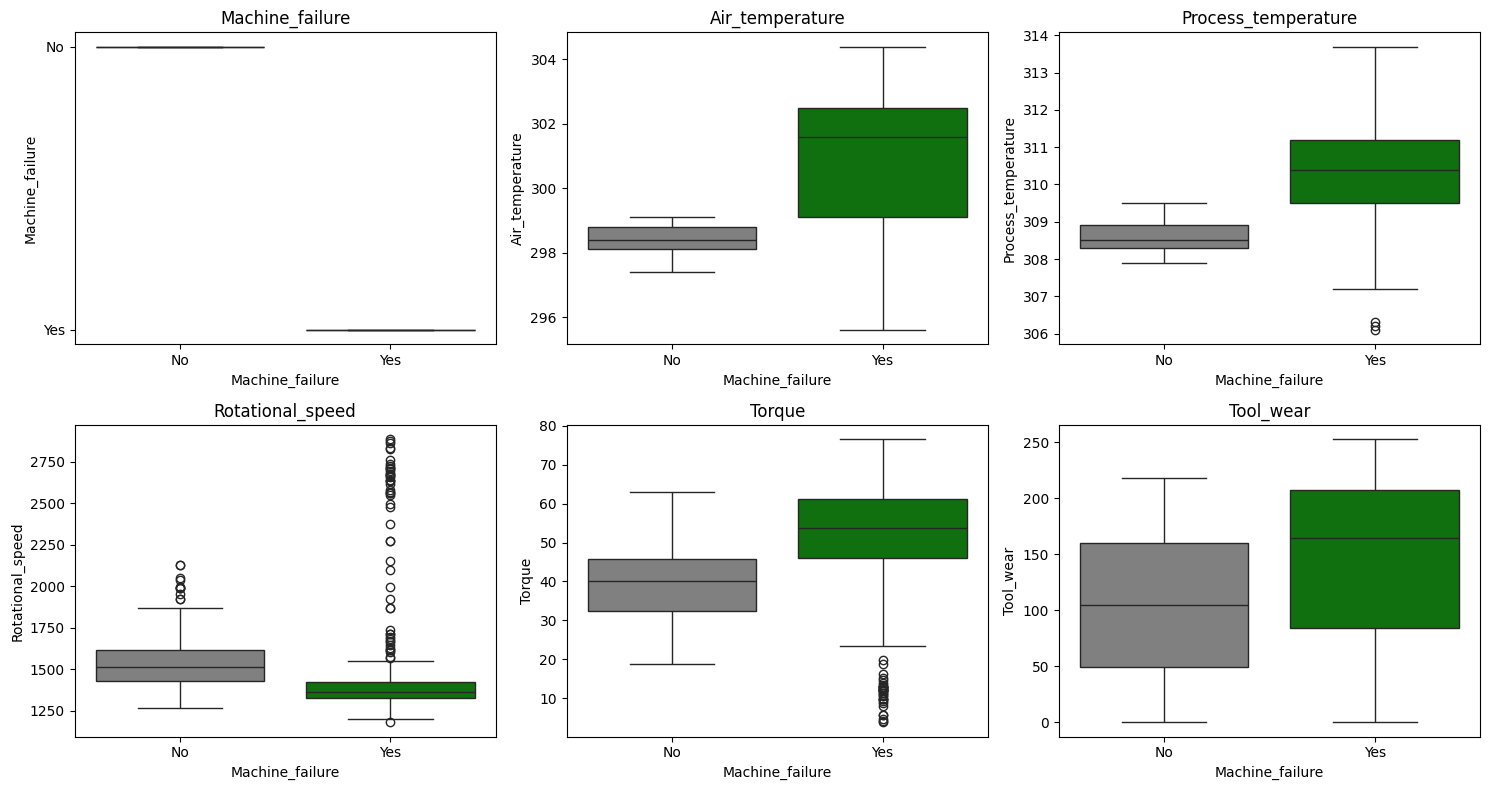

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,8)) #tablero” para poner 6 gráficos.
axes = axes.flatten()

for i, var in enumerate(predictors):
    sns.boxplot(
        data=m_data,
        x="Machine_failure",
        y=var,
        hue="Machine_failure",
        palette={"Yes": "green", "No": "gray"},
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(var)

plt.tight_layout()
plt.show()

C) Which predictors seem more likely to be useful in predicting `Machine_failure`? Justify your answer.

Answer: En este caso las variables de Air Temperature y Process son las gráficas con la separación más clara con y sin falla, lo que indica que pueden ser más valiosas a la hora de hacer las predicciones; por su parte, Torque tiene un poco de sobreposición pero sigue siendo mayor cuando hay falla. En última instancia, se puede concluir que tanto la variable de Rotational speed como la de Tool wear no serían ideales para relaizar las predicciones de falla de máquina ya que existen sobreposicón etre los box_plots; además, dentro de la variable Rotational hay una cifra considerable de datos atípicos (outliers).

## Question 2

A) Set the target category to `Yes`.

In [ ]:
# Set full matrix of predictors.
X_full = m_data.filter(['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear'])

# Set full matrix of responses.
Y_full = m_data['Machine_failure']

In [ ]:
# Create dummy variables.
Y_dummies = pd.get_dummies(Y_full, dtype = 'int')

# Select target variable.
Y_target_full = Y_dummies['Yes']

# Show target variable.
Y_target_full

,Yes
0,0
1,0
2,0
3,0
4,0
...,...
660,1
661,1
662,1
663,1


B) Split the data into training and validation. Use 80% for training and 20% for testing.

In [ ]:
# Split the dataset into training and validation.
X_train, X_test, Y_train, Y_test = train_test_split(X_full, Y_target_full,
                                                      stratify = Y_target_full,
                                                      test_size = 0.2, random_state = 301655)

print("Tamaño de los datos de entrenamiento =", X_train.shape)
print("Tamaño de los datos de prueba =", X_test.shape)

Tamaño de los datos de entrenamiento = (532, 5)
Tamaño de los datos de prueba = (133, 5)


## Question 3

A) Train a K-nearest neighbors algorithm on the training data in order to predict `Machine_failure` using all predictors. Identify the best value of *K* using cross-validation.

In [ ]:
# Definir el operador de standarización.
scaler = StandardScaler()

# Aplicar el operador
Xs_train = scaler.fit_transform(X_train)
Xs_test = scaler.transform(X_test)

In [ ]:
# Set the parameter to be changed and the range of values.
param_grid = {'n_neighbors': range(1, 31)}

# Create a KNeighborsClassifier object
knn_KFoldCV = KNeighborsClassifier()

# Set the grid search using K-fold CVV.
grid_search = GridSearchCV(knn_KFoldCV, param_grid, cv = 5,
                           scoring = 'accuracy')

# Run the search.
grid_search.fit(Xs_train, Y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 31)}, scoring='accuracy')

In [ ]:
k_values = list(param_grid['n_neighbors'])
validation_accuracies = grid_search.cv_results_['mean_test_score']
validation_accuracies

array([0.95672721, 0.93979898, 0.95297126, 0.94734615, 0.958614  ,
       0.94921531, 0.95297126, 0.94921531, 0.95297126, 0.94732851,
       0.95295362, 0.94357256, 0.94544172, 0.9435902 , 0.95108446,
       0.94734615, 0.94921531, 0.94734615, 0.94734615, 0.93979898,
       0.94168577, 0.93040028, 0.93604303, 0.92854876, 0.93230471,
       0.92479281, 0.92666196, 0.91726327, 0.92287075, 0.91535884])

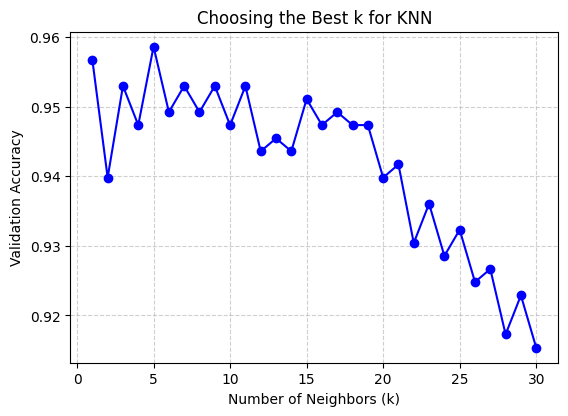

In [ ]:
# 2. Create the plot
plt.figure(figsize=(6.3, 4.3))
plt.plot(k_values, validation_accuracies, marker="o", linestyle="-", color='b')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation Accuracy")
plt.title("Choosing the Best k for KNN")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
best_k = grid_search.best_params_['n_neighbors']
best_k

5

B) Compute the accuracy of the KNN algorithm on the test dataset.

In [ ]:
KNN_final = KNeighborsClassifier(n_neighbors = best_k)
KNN_final.fit(Xs_train, Y_train)

KNeighborsClassifier()

In [ ]:
# DATOS DE TEST
Y_pred_KNNfinal = KNN_final.predict(Xs_test)
test_accuracy = accuracy_score(Y_test, Y_pred_KNNfinal)
print(test_accuracy)

0.9624060150375939


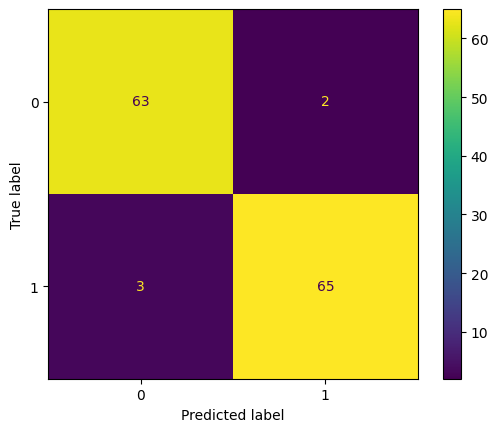

In [ ]:
Y_pred_KNNfinal = KNN_final.predict(Xs_test)
cm = confusion_matrix(Y_test, Y_pred_KNNfinal)
ConfusionMatrixDisplay(cm).plot()

# **# CHECAR SI ES CON LOS DE TEST O ENTRENAMIENTO**

## Question 4

A) Train a classification tree on the training data in order to predict `Machine_failure` using all predictors.

In [ ]:
# Classification tree
clf = DecisionTreeClassifier(min_samples_leaf = 5, ccp_alpha=0, random_state=301655)

# We train the classification tree using the training data.
clf.fit(X_train, Y_train)

DecisionTreeClassifier(ccp_alpha=0, min_samples_leaf=5, random_state=301655)

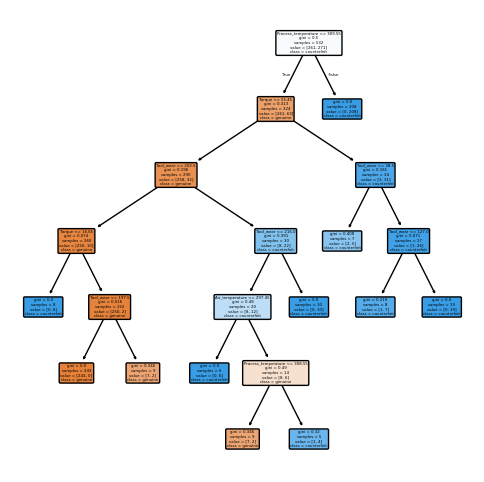

In [ ]:
plt.figure(figsize=(6, 6))
plot_tree(clf, feature_names = X_train.columns,
          class_names=["genuine", "counterfeit"],
          filled=True, rounded=True)
plt.show()

B) Use cost complexity pruning to build an alternative classification tree that predicts `Machine_failure`. Identify the best value of cost complexity pruning using cross-validation.

In [ ]:
path = clf.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas


array([0.        , 0.00033069, 0.00129233, 0.00161117, 0.00403389,
       0.00458289, 0.02868894, 0.04882299, 0.07348023, 0.30903386])

In [ ]:
# 1. Define the grid of parameters
param_grid = {'ccp_alpha': ccp_alphas}

# 2. Set the classification trees using 5-fold CV.
grid_search = GridSearchCV(
    DecisionTreeClassifier(min_samples_leaf = 5, random_state = 301655),
    param_grid,
    cv = 5,
    scoring = 'accuracy'
)

# 3. Train the classification algorithms
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(min_samples_leaf=5,
                                              random_state=301655),
             param_grid={'ccp_alpha': array([0.        , 0.00033069, 0.00129233, 0.00161117, 0.00403389,
       0.00458289, 0.02868894, 0.04882299, 0.07348023, 0.30903386])},
             scoring='accuracy')

In [ ]:
best_alpha = grid_search.best_params_['ccp_alpha']
cv_scores = grid_search.cv_results_['mean_test_score']

print(f"Best Alpha: {best_alpha}")

Best Alpha: 0.00403389425945817


In [ ]:
cv_scores

array([0.95487568, 0.95487568, 0.95487568, 0.95487568, 0.96619644,
       0.96619644, 0.93604303, 0.92482807, 0.90037031, 0.64083936])

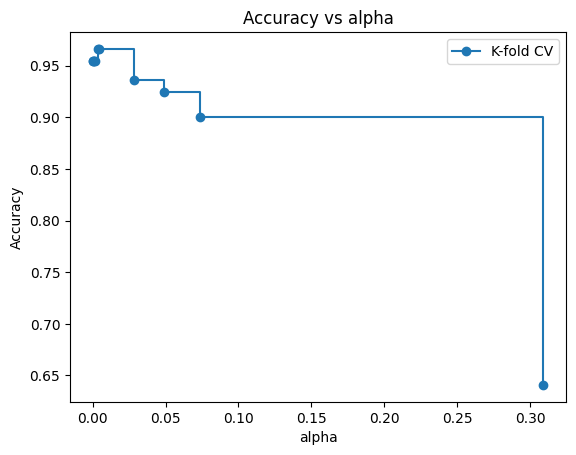

In [ ]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs alpha")
ax.plot(ccp_alphas, cv_scores, marker="o", label="K-fold CV", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# We tell Python that we want a classification tree
clf_simple = DecisionTreeClassifier(min_samples_leaf= 5, ccp_alpha=best_alpha,
                                    random_state = 301655)

# We train the classification tree using the training data.
clf_simple.fit(X_train, Y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.00403389425945817),
                       min_samples_leaf=5, random_state=301655)

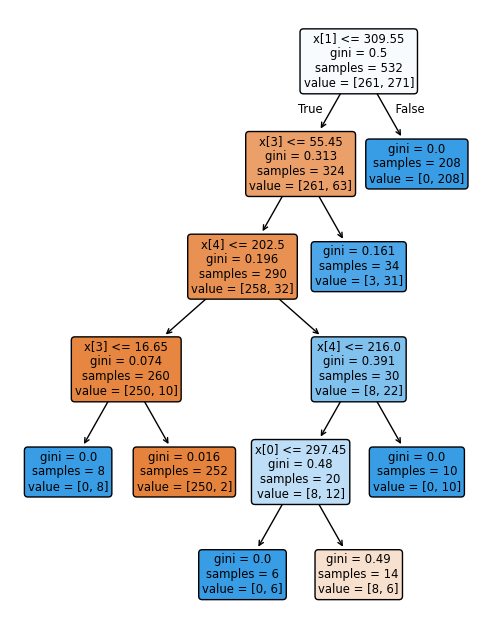

In [ ]:
plt.figure(figsize=(6, 8))
plot_tree(clf_simple, filled=True, rounded=True)
plt.show()

C) Compute the accuracy of both trees on the test dataset.

In [ ]:
# CLASIFICACIÓN ÁRBOL ORIGINAL
original_tree_predictions = clf.predict(X_test)
accuracy_original_tree = accuracy_score(Y_test, original_tree_predictions)
print( "Accuracy del árbol original: ", round(accuracy_original_tree, 4) )

# ÁRBOL PODADO
pruned_tree_predictions = clf_simple.predict(X_test)
accuracy_pruned_tree = accuracy_score(Y_test, pruned_tree_predictions)
print( "Accuracy del árbol podado: ", round(accuracy_pruned_tree, 4) )

Accuracy del árbol original:  0.9549
Accuracy del árbol podado:  0.9624


## Question 5

A) Train a random forest algorithm on the training data for predicting `Machine_failure` using all predictors.

In [ ]:
# Set the bagging algorithm.
RFalgorithm = RandomForestClassifier(n_estimators = 500,
                                     max_features = 'sqrt',
                                     random_state = 301655)

# Train the bagging algorithm.
RFalgorithm.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=500, random_state=301655)

B) Compute the accuracy of the random forest algorithm on the test dataset.

In [ ]:
RF_predicted = RFalgorithm.predict(X_test)
accuracy3 = accuracy_score(Y_test, RF_predicted)

# Show accuracy.
print( "Accuray usando Random Forest:", round(accuracy3, 4) )

Accuray usando Random Forest: 0.985


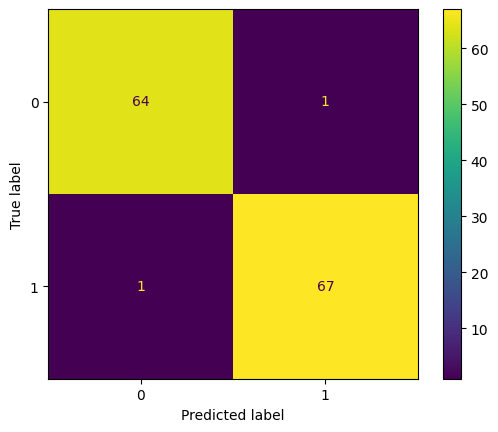

In [ ]:
# Predict class.
RF_predicted = RFalgorithm.predict(X_test)

# Compute confusion matrix.
cm = confusion_matrix(Y_test, RF_predicted)

# Visualize the matrix.
ConfusionMatrixDisplay(cm).plot()

## Question 6

What classification algorithm is best and why?

Answer: En base a la tabla de resultados, el modelo con una mayor exactitud en sus predicciones fue el de Random Forest, con un valor de Accuracy de 0.985. El modelo acertó 131 de 133 casos, como es posible visulizar en la confusion matrix (CM). De manera desglosada, 64 veces el modelo dijo “no falla” y efectivamente no falló, mientras que 67 veces el modelo dijo “falla” y efectivamente falló. Solo hubo 2 casos de falso positivo y falso negativo respectivamente.



In [ ]:
# Create a dictionary with the accuracy results
accuracy_results = {
    'Model': ['K-Nearest Neighbors', 'Classification Tree', 'Pruned Classification Tree', 'Random Forest'],
    'Accuracy': [test_accuracy, accuracy_original_tree, accuracy_pruned_tree, accuracy3]
}

# Create a DataFrame from the dictionary
accuracy_df = pd.DataFrame(accuracy_results)

# Display the DataFrame
print("Accuracy Results:")
display(accuracy_df)

Accuracy Results:


,Model,Accuracy
0,K-Nearest Neighbors,0.962406
1,Classification Tree,0.954887
2,Pruned Classification Tree,0.962406
3,Random Forest,0.984962
